# 14.3.2 字典失配与正则化

## 学习目标与先修知识

比较相同数据上的短字典与闭合字典，解释正则化（regularization）和分布（distribution）外误差。

先修：14.3.1 Koopman 观测（observation）与有限闭合；8.2 正则化。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

若只把 $x,y$ 放进字典，训练的一步误差有时仍很小。缺少 $x^2$ 对新初值（initial condition）有何影响？扩大字典或加入正则化是否自动改善外推？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

固定同一批训练状态（state），先看 $x^2$ 与 $x$ 的关系能否由一个不随状态变化的倍数表示。

In [2]:
for x in [.2,.5,1.5]:print('x=',x,'；x²/x=',x)

x= 0.2 ；x²/x= 0.2
x= 0.5 ；x²/x= 0.5
x= 1.5 ；x²/x= 1.5


## 模型假设

仍用上一节的三角映射，训练状态范围固定在 $|x|\le1$；新初值 $x=1.5$ 留出。短字典 $[x,y]$ 与完整字典 $[x,y,x^2]$ 使用相同训练样本，读出和正则参数（parameter）写明。此比较不靠留出数据选择字典或参数。

## 数学解释与推导

令特征列排成 $Z$、其下一步排成 $W$，约定 $W\approx KZ$ 且 $z^+=Kz$。无正则时 $K=WZ^+$；岭式矩阵（matrix）解为 $K=WZ^\mathsf T(ZZ^\mathsf T+\lambda I)^{-1}$（$\lambda>0$）。短字典遗漏了 $x^2$，因而不闭合；加入这一项后，本例的三角映射可以在字典内传播。正则化（regularization）影响拟合偏差与数值稳定性（numerical stability），可分别用训练误差和留出误差观察。滚动时还需检查预测特征与实际状态的字典值是否一致。

## 核心实现

以下是本节完整计算步骤，可逐行修改。

In [3]:
def triangular_step(state, a, b, c):
    """A nonlinear map whose [x,y,x²] lift closes exactly."""
    x, y = state
    return [a * x, b * y + c * x*x]


def triangular_lift(state):
    x, y = state
    return [x, y, x*x]


def edmd_fit(feature_past, feature_next, ridge):
    """Features are columns; K acts from the left on feature vectors."""
    x = np.asarray(feature_past, dtype=float)
    y = np.asarray(feature_next, dtype=float)
    if ridge == 0:
        return (y @ np.linalg.pinv(x, rcond=1e-12)).tolist()
    gram = x @ x.T + ridge * np.eye(x.shape[0])
    return np.linalg.solve(gram, x @ y.T).T.tolist()


def lifted_roll(operator, readout, initial_feature, steps):
    matrix = np.asarray(operator, dtype=float)
    output = np.asarray(readout, dtype=float)
    feature = np.asarray(initial_feature, dtype=float)
    states = [(output @ feature).tolist()]
    for _ in range(steps):
        feature = matrix @ feature
        states.append((output @ feature).tolist())
    return states

## 对照实验

同一训练网格拟合两种字典，固定留出初值滚动预测，比较无正则与小正则的效果。最后换成饱和清除的教学映射，检查一项新的有限字典是否仍闭合。

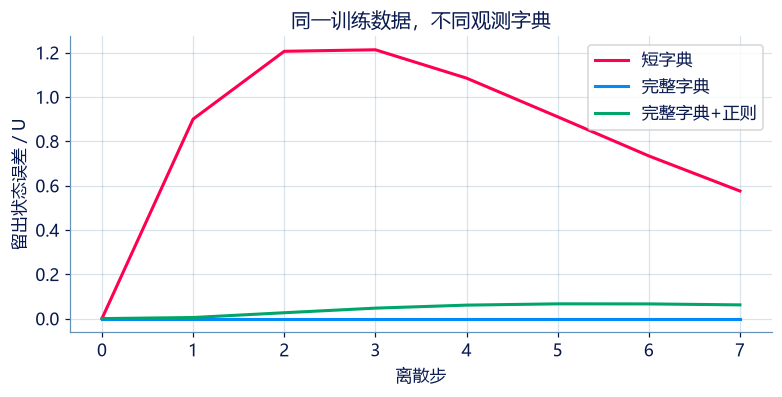

饱和清除留出初值的末步绝对误差 0.100607


In [4]:
a,b,c=.8,.7,.4
starts=[[x,y] for x in [-1.,-.5,.5,1.] for y in [-.2,.2]]
short=np.asarray(starts).T;short_next=np.asarray([triangular_step(s,a,b,c) for s in starts]).T
long=np.asarray([triangular_lift(s) for s in starts]).T
long_next=np.asarray([triangular_lift(triangular_step(s,a,b,c)) for s in starts]).T
Kshort=np.asarray(edmd_fit(short,short_next,0.));Kfull=np.asarray(edmd_fit(long,long_next,0.))
Kridge=np.asarray(edmd_fit(long,long_next,.01));C=np.array([[1.,0.,0.],[0.,1.,0.]])
held=[1.5,.1];actual=[held];state=held
for _ in range(7):state=triangular_step(state,a,b,c);actual.append(state)
actual=np.asarray(actual);short_pred=np.asarray(lifted_roll(Kshort,np.eye(2),held,7))
full_pred=np.asarray(lifted_roll(Kfull,C,triangular_lift(held),7));ridge_pred=np.asarray(lifted_roll(Kridge,C,triangular_lift(held),7))
fig,ax=plt.subplots(figsize=(7,3.5))
for label,path,color in [('短字典',short_pred,PINK),('完整字典',full_pred,BLUE),('完整字典+正则',ridge_pred,GREEN)]:ax.plot(np.linalg.norm(path-actual,axis=1),label=label,color=color)
ax.set(xlabel='离散步',ylabel='留出状态误差 / U',title='同一训练数据，不同观测字典');ax.legend();ax.grid(alpha=.25);plt.show()
def saturating_step(x):
    return x-.15*x/(1+x)
def saturating_lift(x):
    return [x,x/(1+x)]
train_x=np.linspace(.2,1.,30)
sat_past=np.asarray([saturating_lift(x) for x in train_x]).T
sat_next=np.asarray([saturating_lift(saturating_step(x)) for x in train_x]).T
sat_operator=np.asarray(edmd_fit(sat_past,sat_next,0.))
sat_state=2.;sat_truth=[sat_state]
for _ in range(20):sat_state=saturating_step(sat_state);sat_truth.append(sat_state)
sat_pred=np.asarray(lifted_roll(sat_operator,[[1.,0.]],saturating_lift(2.),20))[:,0]
print('饱和清除留出初值的末步绝对误差',round(abs(sat_pred[-1]-sat_truth[-1]),6))

## 结果解释

完整字典能在三角映射中精确闭合；短字典的训练样本不能给出对所有 $x$ 有效的二次项。小正则会引入偏差，它是否值得使用须通过预先分出的验证数据选择，再用独立测试检查。饱和清除映射的两项字典不再精确闭合，一步回归可用并不意味着滚动特征永远对应真实状态。

### 独立核对

核对 $\lambda=0$ 的最小二乘残差（residual）；验证留出误差和小正则的极限（limit）方向。

In [5]:
np.testing.assert_allclose(Kfull,[[a,0,0],[0,b,c],[0,0,a*a]],atol=1e-12)
assert np.linalg.norm(full_pred-actual)<1e-10
assert np.linalg.norm(short_pred-actual)>.1
assert np.linalg.norm(Kridge-Kfull)>0
assert abs(sat_pred[-1]-sat_truth[-1])>1e-4
print('同数据、闭合、短字典失配与正则偏差核验通过。')

同数据、闭合、短字典失配与正则偏差核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/explore/)，再返回此处核对完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：在固定字典中滚动预测

给定已拟合的特征传播矩阵（matrix）、状态（state）读出和初始特征，返回含初态的每步状态预测。

**函数与代码模板**

```python
def solve(
    operator: list[list[float]],
    readout: list[list[float]],
    initial_feature: list[float],
    steps: int,
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `operator` | `list[list[float]]` | d×d 左乘特征矩阵。 | 按特征声明 |
| `readout` | `list[list[float]]` | n×d 状态读出矩阵。 | 按状态/特征 |
| `initial_feature` | `list[float]` | d 维初始特征。 | 按特征声明 |
| `steps` | `int` | 非负预测步数。 | 步 |

**返回值**

直接返回 states（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[list[float]]` | 依次为第0步到第 steps 步的 n 维状态。 | U |

**计算规则**

每步先以 operator 左乘旧特征，再以 readout 取状态；本题不在滚动过程中从预测状态重新生成非线性字典。

**约束与边界**

- 矩阵维度相容；steps≥0；全部输入（input）有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| operator | d×d 左乘特征矩阵。 | [[0.8, 0.0], [0.0, 0.5]] | 按特征声明 |
| readout | n×d 状态读出矩阵。 | [[1.0, 1.0]] | 按状态/特征 |
| initial_feature | d 维初始特征。 | [2.0, 1.0] | 按特征声明 |
| steps | 非负预测步数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
operator = [[0.8, 0.0], [0.0, 0.5]]
readout = [[1.0, 1.0]]
initial_feature = [2.0, 1.0]
steps = 2

result = solve(operator, readout, initial_feature, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 依次为第0步到第 steps 步的 n 维状态。 | [[3.0], [2.1], [1.5300000000000002]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[3.0], [2.1], [1.5300000000000002]]
```

**样例解释**

首例第0步读数为3，第一步为2.1，第二步为1.53；始终使用同一个特征传播。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：在固定字典中滚动预测](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/practice/?question=p14-lifted-roll)

### 第 2 题 · 单项选择题：字典变大一定好吗

增加字典项后训练残差（residual）下降，哪项仍不能直接得出？

- **A.** 独立初值（initial condition）和分布（distribution）外预测必改善。
- **B.** 较大的字典改变了表示空间。
- **C.** 需要检查条件数（condition number）与正则选择。
- **D.** 需要单独报告读出误差。

[作答：字典变大一定好吗](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/practice/?question=p14-dictionary-mismatch)

### 第 3 题 · 单项选择题：正则参数的选择

本节岭参数（parameter） ridge>0 的直接数学作用是什么？

- **A.** 改变拟合矩阵（matrix），通常引入偏差并改善某些病态情形。
- **B.** 保证学到真实机制。
- **C.** 自动让有限字典精确闭合。
- **D.** 让训练与测试数据可以混用。

[作答：正则参数的选择](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/practice/?question=p14-ridge-bias)

### 第 4 题 · 单项选择题：线性滚动后的特征

有限字典不闭合时，Kz 滚动后可能出现什么？

- **A.** 预测特征未必等于预测状态（state）重新代入字典的值。
- **B.** 每一步必仍是某个真实状态的精确字典。
- **C.** 读出矩阵（matrix）必不存在。
- **D.** 此问题只能用更多绘图点修复。

[作答：线性滚动后的特征](http://127.0.0.1:8000/chapters/14-03-Koopman%20%E8%A1%A8%E7%A4%BA%E4%B8%8E%E6%9C%89%E9%99%90%E5%AD%97%E5%85%B8/practice/?question=p14-feature-drift)

**进一步阅读**

[Williams 等人的 EDMD 论文](https://doi.org/10.1007/s00332-015-9258-5)讨论字典近似；本节所有模型共享同一训练网格。